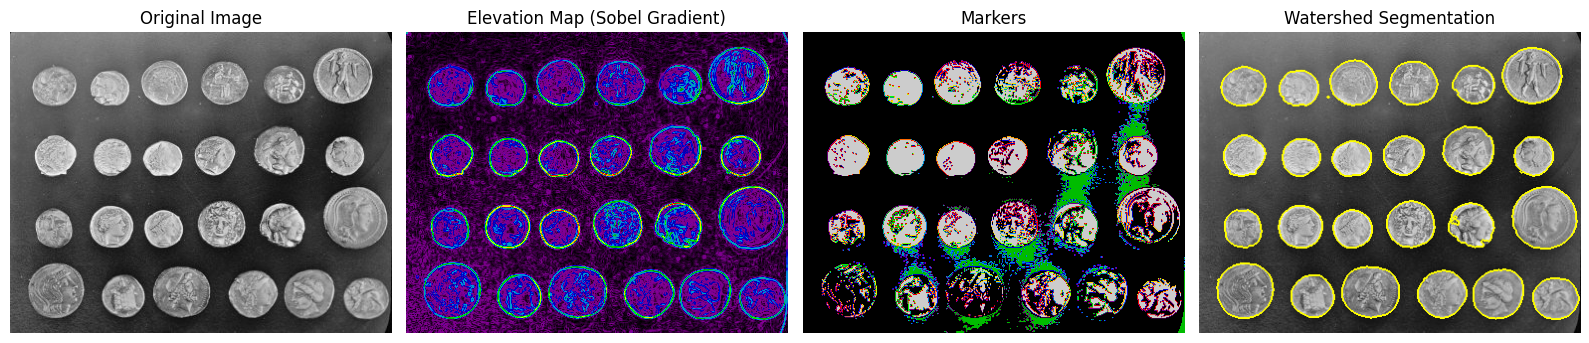

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, morphology, measure
from scipy import ndimage as ndi

# 1. Memuat citra (contoh: coins)
image_coins = data.coins()

# 2. Hitung gradien citra (sebagai 'topografi')
elevation_map = filters.sobel(image_coins)

# 3. Tentukan marker (penanda awal untuk setiap cekungan/objek)
# Kita bisa menggunakan thresholding untuk mendapatkan marker kasar
markers = np.zeros_like(image_coins)
markers[image_coins < 30] = 1 # Marker untuk latar belakang
markers[image_coins > 150] = 2 # Marker untuk objek (koin)

# Atau gunakan marker dari local maxima (lebih canggih)
# from skimage.feature import peak_local_max
# image_max = ndi.maximum_filter(image_coins, size=20, mode='constant')
# coordinates = peak_local_max(image_coins, min_distance=20)
# markers = np.zeros(image_coins.shape, dtype=bool)
# markers[tuple(coordinates.T)] = True
# markers = measure.label(markers)

# 4. Terapkan algoritma Watershed
segmentation_watershed = segmentation.watershed(elevation_map, markers)

# Warnai hasil segmentasi untuk visualisasi
segmented_colored = segmentation.mark_boundaries(image_coins, segmentation_watershed)

# 5. Visualisasi Hasil
fig, axes = plt.subplots(ncols=4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(elevation_map, cmap=plt.cm.nipy_spectral)
ax[1].set_title('Elevation Map (Sobel Gradient)')
ax[1].axis('off')

ax[2].imshow(markers, cmap=plt.cm.nipy_spectral)
ax[2].set_title('Markers')
ax[2].axis('off')

ax[3].imshow(segmented_colored)
ax[3].set_title('Watershed Segmentation')
ax[3].axis('off')

plt.tight_layout()
plt.show()

Tugas Lanjutan:
Amati bagaimana algoritma Watershed menggunakan gradien dan marker untuk memisahkan objek. Bagaimana pemilihan marker mempengaruhi hasil akhir? Apa yang terjadi jika marker tidak tepat?

PENGARUH PEMILIHAN MARKER PADA WATERSHED SEGMENTATION


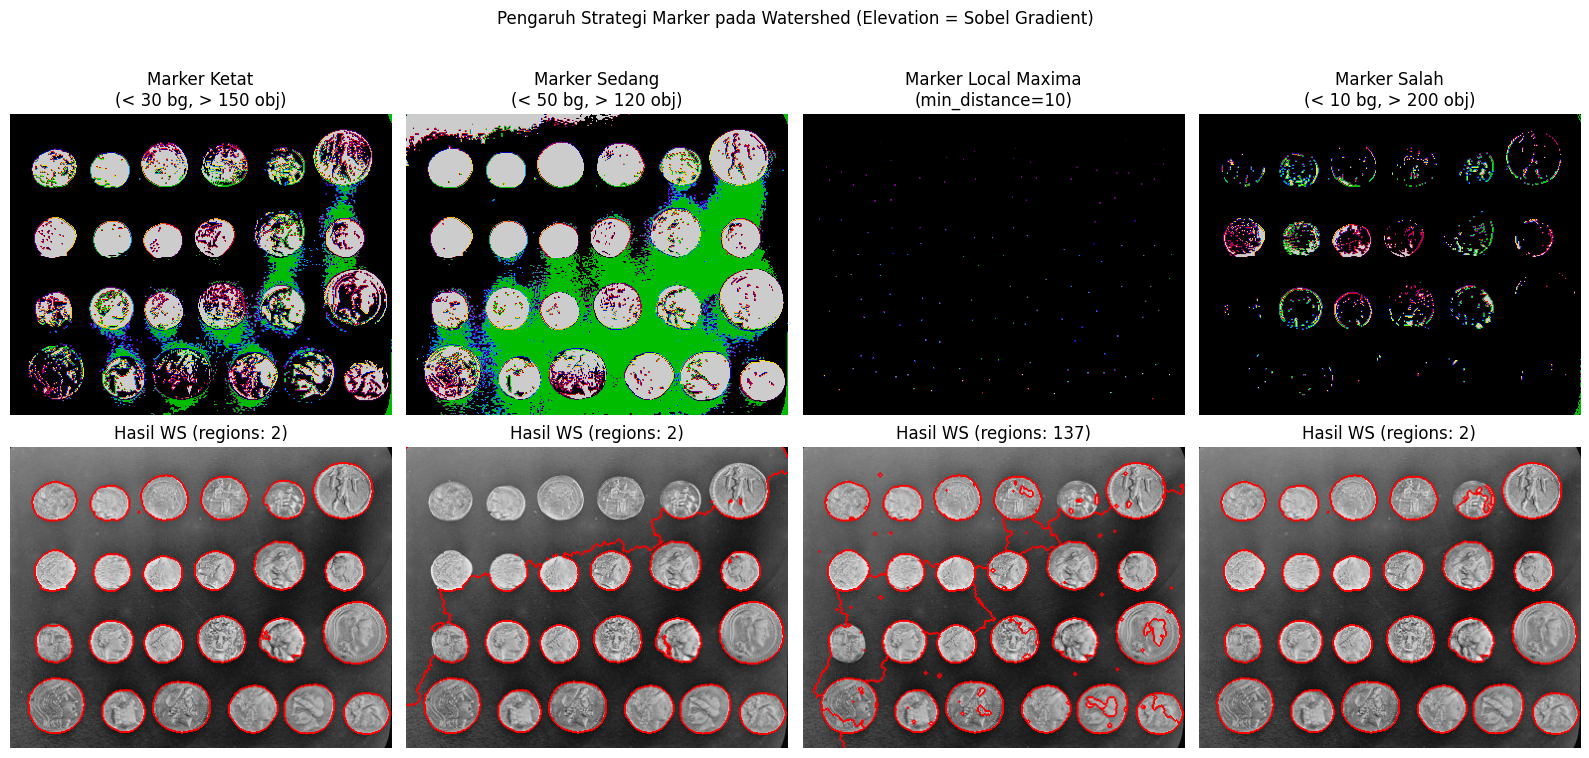


✓ HASIL PERBANDINGAN:
Marker Ketat      → 2 regions (mungkin under-segment)
Marker Sedang     → 2 regions (balance)
Local Maxima      → 137 regions (detail, tapi kompleks)
Marker Salah      → 2 regions (over/under-segment)

✓ KESIMPULAN:
- Marker yang tepat sangat penting untuk Watershed
- Marker terlalu ketat → under-segmentation (region terlewat)
- Marker terlalu longgar → over-segmentation (banyak region kecil)
- Local maxima: otomatis tapi kompleks, perlu tuning min_distance


In [3]:
# Tugas Lanjutan: Pengaruh pemilihan marker pada Watershed
print("=" * 60)
print("PENGARUH PEMILIHAN MARKER PADA WATERSHED SEGMENTATION")
print("=" * 60)

# Elevation map sudah ada dari code sebelumnya
# Coba beberapa strategi marker yang berbeda

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Strategi 1: Marker threshold ketat (current)
markers1 = np.zeros_like(image_coins)
markers1[image_coins < 30] = 1
markers1[image_coins > 150] = 2
ws1 = segmentation.watershed(elevation_map, markers1)

axes[0, 0].imshow(markers1, cmap='nipy_spectral')
axes[0, 0].set_title('Marker Ketat\n(< 30 bg, > 150 obj)')
axes[0, 0].axis('off')

seg1 = segmentation.mark_boundaries(image_coins, ws1, color=(1,0,0))
axes[1, 0].imshow(seg1)
axes[1, 0].set_title(f'Hasil WS (regions: {np.max(ws1)})')
axes[1, 0].axis('off')

# Strategi 2: Marker lebih longgar
markers2 = np.zeros_like(image_coins)
markers2[image_coins < 50] = 1
markers2[image_coins > 120] = 2
ws2 = segmentation.watershed(elevation_map, markers2)

axes[0, 1].imshow(markers2, cmap='nipy_spectral')
axes[0, 1].set_title('Marker Sedang\n(< 50 bg, > 120 obj)')
axes[0, 1].axis('off')

seg2 = segmentation.mark_boundaries(image_coins, ws2, color=(1,0,0))
axes[1, 1].imshow(seg2)
axes[1, 1].set_title(f'Hasil WS (regions: {np.max(ws2)})')
axes[1, 1].axis('off')

# Strategi 3: Marker dari local maxima (lebih canggih)
from skimage.feature import peak_local_max
markers3 = np.zeros_like(image_coins)
# peak_local_max returns coordinates (rows, cols)
local_maxi = peak_local_max(image_coins, min_distance=10)
# Create boolean mask dari coordinates
local_maxi_mask = np.zeros_like(image_coins, dtype=bool)
for coord in local_maxi:
    local_maxi_mask[coord[0], coord[1]] = True
markers3 = measure.label(local_maxi_mask)
markers3[image_coins < 30] = 0  # Background
ws3 = segmentation.watershed(elevation_map, markers3)

axes[0, 2].imshow(markers3, cmap='nipy_spectral')
axes[0, 2].set_title('Marker Local Maxima\n(min_distance=10)')
axes[0, 2].axis('off')

seg3 = segmentation.mark_boundaries(image_coins, ws3, color=(1,0,0))
axes[1, 2].imshow(seg3)
axes[1, 2].set_title(f'Hasil WS (regions: {np.max(ws3)})')
axes[1, 2].axis('off')

# Strategi 4: Marker salah (tujuan: lihat over/under-segmentation)
markers4 = np.zeros_like(image_coins)
markers4[image_coins < 10] = 1   # Terlalu ketat
markers4[image_coins > 200] = 2  # Terlalu ketat
ws4 = segmentation.watershed(elevation_map, markers4)

axes[0, 3].imshow(markers4, cmap='nipy_spectral')
axes[0, 3].set_title('Marker Salah\n(< 10 bg, > 200 obj)')
axes[0, 3].axis('off')

seg4 = segmentation.mark_boundaries(image_coins, ws4, color=(1,0,0))
axes[1, 3].imshow(seg4)
axes[1, 3].set_title(f'Hasil WS (regions: {np.max(ws4)})')
axes[1, 3].axis('off')

plt.suptitle('Pengaruh Strategi Marker pada Watershed (Elevation = Sobel Gradient)', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print(f"\n✓ HASIL PERBANDINGAN:")
print(f"Marker Ketat      → {np.max(ws1)} regions (mungkin under-segment)")
print(f"Marker Sedang     → {np.max(ws2)} regions (balance)")
print(f"Local Maxima      → {np.max(ws3)} regions (detail, tapi kompleks)")
print(f"Marker Salah      → {np.max(ws4)} regions (over/under-segment)")

print(f"\n✓ KESIMPULAN:")
print(f"- Marker yang tepat sangat penting untuk Watershed")
print(f"- Marker terlalu ketat → under-segmentation (region terlewat)")
print(f"- Marker terlalu longgar → over-segmentation (banyak region kecil)")
print(f"- Local maxima: otomatis tapi kompleks, perlu tuning min_distance")